<a href="https://colab.research.google.com/github/Chiara-Natali/Smart-Vacuum/blob/main/Smart_Vacuum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Addestramento CNN

### Import

In [ ]:
import cv2
import numpy as np
import sys
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from typing import Tuple, List
from tensorflow.keras.preprocessing.image import ImageDataGenerator

!pip install -U tensorflow-datasets
import tensorflow_datasets as tfds

### Dataset

In [ ]:

emnist_map = {'S': 19, 'F': 6, 'D': 4, 'V': 22, 'X': 24, 'C': 3}
classes = list(emnist_map.keys())
indices = list(emnist_map.values())

print("Scaricamento e caricamento eMNIST in corso...")
ds_train, ds_test = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=False
)

def ds_to_numpy(ds):
    images, labels = [], []
    for img, lbl in ds.as_numpy_iterator():
        images.append(img)
        labels.append(lbl)
    return np.array(images), np.array(labels)

x_raw_train, y_raw_train = ds_to_numpy(ds_train)
x_raw_test, y_raw_test = ds_to_numpy(ds_test)

def fix_emnist_axes(images):
    return np.array([np.transpose(img, (1, 0, 2)) for img in images])

print("Correzione orientamento e unione dataset...")
x_raw_train = fix_emnist_axes(x_raw_train)
x_raw_test = fix_emnist_axes(x_raw_test)

x_all = np.concatenate((x_raw_train, x_raw_test), axis=0)
y_all = np.concatenate((y_raw_train, y_raw_test), axis=0)

def filter_and_remap(x, y, target_indices):
    mask = np.isin(y, target_indices)
    x_filtered = x[mask]
    y_filtered = y[mask]

    y_remapped = np.zeros_like(y_filtered)
    for i, orig_idx in enumerate(target_indices):
        y_remapped[y_filtered == orig_idx] = i

    return x_filtered, y_remapped

x_filtered, y_filtered = filter_and_remap(x_all, y_all, indices)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    x_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# Normalizzazione e Reshape
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

if X_train.shape[1] != 28:
    X_train = tf.image.resize(X_train, [28, 28]).numpy()
    X_test = tf.image.resize(X_test, [28, 28]).numpy()

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.20,
    height_shift_range=0.20,
    zoom_range=0.15,
    shear_range=0.10,
    fill_mode='constant',
    cval=0
)

datagen.fit(X_train)

Scaricamento e caricamento eMNIST in corso...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.DP0J74_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.DP0J74_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Correzione orientamento e unione dataset...
Lettera S (orig 19): 3792 campioni trovati.
Lettera F (orig 6): 4194 campioni trovati.
Lettera D (orig 4): 4198 campioni trovati.
Lettera V (orig 22): 3422 campioni trovati.
Lettera X (orig 24): 3437 campioni trovati.
Lettera C (orig 3): 4219 campioni trovati.


'\n# Debug\nplt.figure(figsize=(10, 3))\nfor i in range(5):\n    plt.subplot(1, 5, i+1)\n    plt.imshow(X_train[i].reshape(28, 28), cmap=\'gray\')\n    plt.title(f"Label: {classes[y_train[i]]}")\n    plt.axis(\'off\')\nplt.show()\n'

### Training

In [ ]:
# Definizione del modello
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Avvia addestramento
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=256),
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stop]
)

model.save("model_1222.h5")
print("\nModello salvato con successo!")



Modello salvato con successo!


### Stats

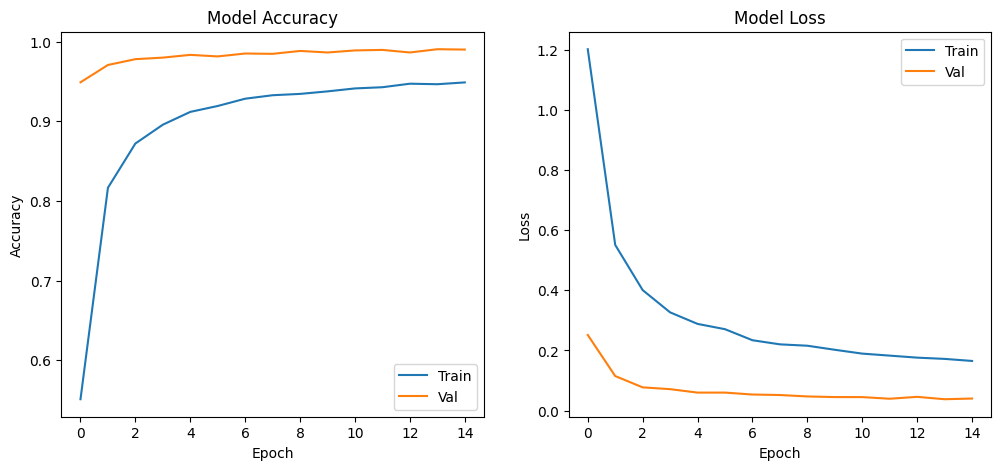

146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


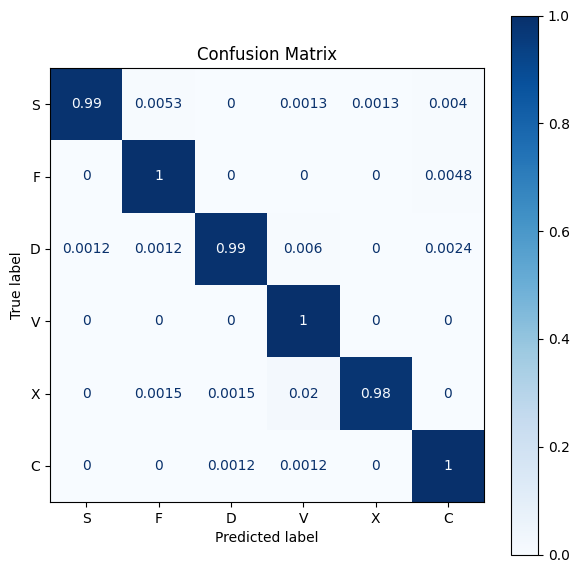


Report di classificazione:
              precision    recall  f1-score   support

           S       1.00      0.99      0.99       759
           F       0.99      1.00      0.99       839
           D       1.00      0.99      0.99       840
           V       0.97      1.00      0.98       684
           X       1.00      0.98      0.99       687
           C       0.99      1.00      0.99       844

    accuracy                           0.99      4653
   macro avg       0.99      0.99      0.99      4653
weighted avg       0.99      0.99      0.99      4653



In [ ]:
# Creazione Plot
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(7,7))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

print("\nReport di classificazione:")
print(classification_report(y_test, y_pred, target_names=classes))


# Cell Classifier (Computer Vision)

### Outerline

In [ ]:
# Ritaglia bordo esterno della griglia
def find_grid_box(gray, thresh_block_size: int = 11, thresh_C: int = 2) -> Tuple[int, int, int, int]:
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, thresh_block_size, thresh_C
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    img_h, img_w = gray.shape
    image_area = img_h * img_w

    best_cont  = None
    best_area = 0
    for cont in contours:
        area = cv2.contourArea(cont)
        if area < image_area * 0.10 or area > image_area * 0.95:
            continue

        x, y, w, h = cv2.boundingRect(cont)
        aspect = max(w, h) / (min(w, h) + 1e-5)
        if aspect > 1.5:
            continue

        if area > best_area:
            best_area = area
            best_cont  = cont

    if best_cont is None:
        raise RuntimeError("Griglia non trovata nell'immagine.")

    gx, gy, gw, gh = cv2.boundingRect(best_cont)
    pad = int(min(gw, gh) * 0.025)

    return (gx + pad, gy + pad, gw - 2*pad, gh - 2*pad)

### Inner lines

In [ ]:
# Raggruppa i centri vicini
def cluster(coords: List[float], gap: int = 30) -> List[int]:
    if not coords:
        return []
    coords = sorted(coords)
    clusters = [[coords[0]]]
    for c in coords[1:]:
        if c - clusters[-1][-1] < gap:
            clusters[-1].append(c)
        else:
            clusters.append([c])
    return [int(np.mean(cl)) for cl in clusters]

# Chiude le linee
def add_borders(coords: List[int], size: int, margin: int = 30) -> List[int]:
    if not coords or coords[0] > margin:
        coords = [0] + coords
    if coords[-1] < size - margin:
        coords = coords + [size]
    return coords

# Trova confini delle celle
def detect_grid_lines(grid_gray: np.ndarray) -> Tuple[List[int], List[int]]:
    gh, gw = grid_gray.shape

    blur  = cv2.GaussianBlur(grid_gray, (3, 3), 0)
    edges = cv2.Canny(blur, 30, 120, apertureSize=3)

    dil_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.dilate(edges, dil_kernel, iterations=1)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=60,
        minLineLength=int(min(gw, gh) * 0.35),
        maxLineGap=25
    )

    h_coords, v_coords = [], []

    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            if angle < 20:
                h_coords.append((y1 + y2) / 2)
            elif angle > 70:
                v_coords.append((x1 + x2) / 2)

    rows = add_borders(cluster(h_coords), gh)
    cols = add_borders(cluster(v_coords), gw)

    if len(rows) != 4:
        print(f"[WARN] Trovate {len(rows)-1} righe — uso divisione uniforme.")
        n = round((gh / gw) * 3) if gw > 0 else 3
        rows = [int(i * gh / n) for i in range(n + 1)]

    if len(cols) != 4:
        print(f"[WARN] Trovate {len(cols)-1} colonne — uso divisione uniforme.")
        n = 3
        cols = [int(i * gw / n) for i in range(n + 1)]

    return rows, cols

### Letters Detection

In [ ]:
# Estrae caratteri dalle celle
def extract_and_classify_cells(
    grid_gray : np.ndarray,
    rows       : List[int],
    cols       : List[int],
    model      : tf.keras.Model,
    classes    : List[str],
    margin_ratio: float = 0.10
) -> Tuple[List[List[str]], List[np.ndarray]]:

    grid_letters = []
    all_centered_imgs = []

    for i in range(len(rows) - 1):
        row_letters = []
        for j in range(len(cols) - 1):
            y0, y1 = rows[i], rows[i + 1]
            x0, x1 = cols[j], cols[j + 1]

            cell_h = y1 - y0
            cell_w = x1 - x0

            my = max(int(cell_h * margin_ratio), 2)
            mx = max(int(cell_w * margin_ratio), 2)

            roi = grid_gray[y0+my : y1-my, x0+mx : x1-mx]

            if roi.size == 0:
                row_letters.append('?')
                all_centered_imgs.append(np.zeros((28, 28), dtype=np.uint8))
                continue

            _, roi_bin = cv2.threshold(
                roi, 0, 255,
                cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU
            )

            contours_char, _ = cv2.findContours(roi_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if not contours_char:
                letter = '?' # Cella vuota '?'
                centered_img_for_model = np.zeros((28, 28), dtype=np.uint8)
            else:
                largest_contour = max(contours_char, key=cv2.contourArea)
                x_char, y_char, w_char, h_char = cv2.boundingRect(largest_contour)

                if w_char == 0 or h_char == 0:
                    letter = '?'
                    centered_img_for_model = np.zeros((28, 28), dtype=np.uint8)
                else:
                    centered_img_for_model = np.zeros((28, 28), dtype=np.uint8) # canvas nero

                    # ridimensionamento carattere e roi
                    scale_factor = min(20 / w_char, 20 / h_char)
                    resized_char_w = int(w_char * scale_factor)
                    resized_char_h = int(h_char * scale_factor)

                    if resized_char_w == 0: resized_char_w = 1
                    if resized_char_h == 0: resized_char_h = 1

                    char_roi = roi_bin[y_char : y_char + h_char, x_char : x_char + w_char]

                    resized_char = cv2.resize(char_roi, (resized_char_w, resized_char_h), interpolation=cv2.INTER_AREA)

                    paste_x = (28 - resized_char.shape[1]) // 2
                    paste_y = (28 - resized_char.shape[0]) // 2

                    centered_img_for_model[paste_y : paste_y + resized_char.shape[0],
                                           paste_x : paste_x + resized_char.shape[1]] = resized_char

                    img_input   = centered_img_for_model.reshape(1, 28, 28, 1).astype("float32") / 255.0
                    pred        = model.predict(img_input, verbose=0)[0]
                    letter      = classes[np.argmax(pred)]

            row_letters.append(letter)
            all_centered_imgs.append(centered_img_for_model)
        grid_letters.append(row_letters)

    return grid_letters, all_centered_imgs

# Debug Image
def visualize_cells(
    grid_gray: np.ndarray,
    grid_letters: List[List[str]],
    rows: List[int],
    cols: List[int],
    centered_cell_images: List[np.ndarray]
):
    n_rows = len(rows) - 1
    n_cols = len(cols) - 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    img_idx = 0
    for r_idx in range(n_rows):
        for c_idx in range(n_cols):
            ax  = axes[r_idx, c_idx]
            ax.imshow(centered_cell_images[img_idx], cmap='gray')
            ax.set_title(f"({r_idx},{c_idx}): {grid_letters[r_idx][c_idx]}")
            ax.axis('off')
            img_idx += 1

    plt.suptitle("Celle rilevate", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
def classify_grid(
    model_path: str,
    image_path: str,
    bbox_thresh_block_size: int = 11,
    bbox_thresh_C: int = 2
) -> List[List[str]]:
    classes = ['S', 'F', 'D', 'V', 'X', 'C']

    model = tf.keras.models.load_model(model_path, compile=False)
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Immagine non trovata: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gx, gy, gw, gh = find_grid_box(gray, bbox_thresh_block_size, bbox_thresh_C)
    grid_gray = gray[gy:gy+gh, gx:gx+gw]

    rows, cols = detect_grid_lines(grid_gray)
    print(f"Griglia rilevata: {len(rows)-1} righe × {len(cols)-1} colonne")

    grid_letters = extract_and_classify_cells(grid_gray, rows, cols, model, classes)

    grid_letters, centered_images = extract_and_classify_cells(grid_gray, rows, cols, model, classes)
    # visualize_cells(grid_gray, grid_letters, rows, cols, centered_images)

    print("\n── Griglia riconosciuta ──")
    for row in grid_letters:
        print(' | '.join(row))

    return grid_letters

# Logica (Path Search)

In [ ]:
!git clone https://github.com/aimacode/aima-python.git

Cloning into 'aima-python'...
remote: Enumerating objects: 5095, done.
remote: Total 5095 (delta 0), reused 0 (delta 0), pack-reused 5095 (from 1)
Receiving objects: 100% (5095/5095), 17.44 MiB | 19.04 MiB/s, done.
Resolving deltas: 100% (3418/3418), done.


In [ ]:
sys.path.append("/content/aima-python")
from search import *

class SmartVacuum(Problem):
    def __init__(self, initial_grid, start_pos, goal_pos):
        self.initial = (start_pos, tuple(tuple(row) for row in initial_grid))
        self.goal_pos = goal_pos
        self.rows = len(initial_grid)
        self.cols = len(initial_grid[0])

    # Restituisce le azioni possibili dallo stato corrente
    def actions(self, state):
        curr_pos, grid = state
        row, col = curr_pos
        curr_cell_status = grid[row][col]
        possible_actions = []

        if curr_cell_status in ('D', 'V'):
            possible_actions.append("Suck")

        for delta_row, delta_col, move in [(-1, 0, 'Up'), (1, 0, 'Down'), (0, -1, 'Left'), (0, 1, 'Right')]:
            next_row, next_col = row + delta_row, col + delta_col
            if 0 <= next_row < self.rows and 0 <= next_col < self.cols:
                if grid[next_row][next_col] != 'X':
                    possible_actions.append(move)
        return possible_actions

    # Restituisce lo stato risultante dall'esecuzione di un'azione
    def result(self, state, action):
        curr_pos, grid = state
        r, c = curr_pos
        new_grid = [list(row) for row in grid]
        new_pos = curr_pos

        if action == "Suck":
            if new_grid[r][c] == 'V':
                new_grid[r][c] = 'D'
            elif new_grid[r][c] == 'D':
                new_grid[r][c] = 'C'
        else:
            moves = {'Up': (-1, 0), 'Down': (1, 0), 'Left': (0, -1), 'Right': (0, 1)}
            dr, dc = moves[action]
            new_pos = (r + dr, c + dc)

        return (new_pos, tuple(tuple(row) for row in new_grid))

    # Verifica se lo stato corrente è un goal
    def goal_test(self, state):
        curr_pos, grid = state
        if curr_pos != self.goal_pos:
            return False
        for row in grid:
            if 'D' in row or 'V' in row:
                return False
        return True

    # Calcola il costo del percorso per raggiungere lo stato successivo
    def path_cost(self, c, state1, action, state2):
        return c + 1

    # Funzione euristica per la ricerca A*.
    def h(self, node):
        curr_pos, grid = node.state
        curr_r, curr_c = curr_pos

        dirty_rooms = []
        total_cleaning_effort = 0

        for r in range(len(grid)):
            for c in range(len(grid[0])):
                status = grid[r][c]
                if status == 'D':
                    dirty_rooms.append((r, c))
                    total_cleaning_effort += 1
                elif status == 'V':
                    dirty_rooms.append((r, c))
                    total_cleaning_effort += 2
        if not dirty_rooms:
            r_goal, c_goal = self.goal_pos
            return abs(curr_r - r_goal) + abs(curr_c - c_goal)

        dist_to_nearest = min(abs(curr_r - dr) + abs(curr_c - dc) for dr, dc in dirty_rooms)
        return dist_to_nearest + total_cleaning_effort

# Main

### Elaborazione Input

In [ ]:
MODEL_PATH = "/content/model_1222.h5"
IMAGE_PATH = "/content/grid2.jpeg"
# display_contours(IMAGE_PATH)

try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"Modello '{MODEL_PATH}' caricato correttamente.")
except Exception as e:
    print(f"Errore nel caricamento del modello: {e}")
    sys.exit()

print("Analisi dell'immagine in corso...")
detected_grid = classify_grid(MODEL_PATH, IMAGE_PATH)

if not detected_grid or not detected_grid[0] or len(detected_grid) != 3 or any(len(row) != 3 for row in detected_grid):
    print(f"Errore: Rilevata una griglia di dimensioni inattese. Expected 3x3, got {len(detected_grid)}x{len(detected_grid[0]) if detected_grid else 0}.")
    sys.exit()

grid = detected_grid

start_pos = None
goal_pos = None
for r in range(len(grid)):
    for c in range(len(grid[0])):
        if grid[r][c] == 'S':
            start_pos = (r, c)
        if grid[r][c] == 'F':
            goal_pos = (r, c)

if not start_pos or not goal_pos:
    print("Errore: 'S' o 'F' non trovate nella griglia riconosciuta.")
    sys.exit()

print(f"Start position (S): {start_pos}")
print(f"Goal position (F): {goal_pos}")

Modello '/content/model_1222.h5' caricato correttamente.
Analisi dell'immagine in corso...
Griglia rilevata: 3 righe × 3 colonne

── Griglia riconosciuta ──
D | D | F
X | V | X
C | C | S
Start position (S): (2, 2)
Goal position (F): (0, 2)


### Soluzione

In [ ]:
problem = SmartVacuum(grid, start_pos, goal_pos)

choice = input("\nScegli:\n[1] A*\n[2] BFS\n")

if choice not in ['1', '2']:
    print("Scelta non valida. Utilizzo A* di default.")
    choice = '1'

if choice == '1':
  node = astar_search(problem, h=problem.h)
  print("\nSoluzione trovata con A*:")
elif choice == '2':
  node = breadth_first_tree_search(problem)
  print("\nSoluzione trovata con BFS:")

if node:
  print(node.solution())
  states = [n.state for n in node.path()]
  positions= [pos[0] for pos in states]
  positions= list(set(positions))
  print(f"Attraversati {len(positions)} nodi")
else:
  print("Nessuna soluzione trovata.")


Scegli:
[1] A*
[2] BFS
1

Soluzione trovata con A*:
Nessuna soluzione trovata.


# Animazione

In [ ]:
if node:
    # Ricostruzione della sequenza di stati
    states = [problem.initial]
    current_state = problem.initial

    for action in node.solution():
        current_state = problem.result(current_state, action)
        states.append(current_state)

    all_actions = ["Start"] + node.solution()

    # mappa dei colori
    cell_colors_map = {
        'S': 1,
        'F': 0,
        'V': 2,
        'D': 3,
        'C': 4,
        'X': 5
    }

    # verde, grigio, viola scuro, viola magenta, bianco, rosso
    cmap_list = ['#2ca02c', '#808080', '#520052', '#A300A3', '#ffffff', '#ff0000']
    cmap = plt.cm.colors.ListedColormap(cmap_list)

    sorted_unique_values = sorted(list(set(cell_colors_map.values())))
    bounds = np.array(sorted_unique_values) - 0.5
    bounds = np.append(bounds, max(cell_colors_map.values()) + 0.5)
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

    fig, (ax, ax_text) = plt.subplots(
        1, 2,
        figsize=(9, 6),
        gridspec_kw={'width_ratios': [4, 2]}
    )

    # Configurazione asse griglia
    ax.set_xticks(np.arange(problem.cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(problem.rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
    ax.set_xticks([])
    ax.set_yticks([])

    img_plot = ax.imshow(np.zeros((problem.rows, problem.cols)), cmap=cmap, norm=norm,
                        origin='upper', extent=[-0.5, problem.cols - 0.5, problem.rows - 0.5, -0.5])

    # Pallino e testo laterale
    robot_marker, = ax.plot([], [], 'o', color='yellow', markersize=20, zorder=5)

    cell_char_texts = [
        [ax.text(c, r, '', ha='center', va='center', color='black', fontsize=10) for c in range(problem.cols)]
        for r in range(problem.rows)
    ]

    ax_text.axis('off')
    action_text = ax_text.text(0.05, 0.75, '', transform=ax_text.transAxes,
                                color='black', fontsize=12, verticalalignment='top')
    status_text = ax_text.text(0.05, 0.55, '', transform=ax_text.transAxes,
                                color='black', fontsize=12, verticalalignment='top')

    plt.tight_layout()

    # Aggiorna contenuto cella e action_text
    def update(frame):
        current_pos, current_grid_tuple = states[frame]
        current_action = all_actions[frame]

        grid_numeric = np.zeros((problem.rows, problem.cols))
        for r in range(problem.rows):
            for c in range(problem.cols):
                cell_val = current_grid_tuple[r][c]

                if (r, c) == start_pos and cell_val == 'C':
                    grid_numeric[r, c] = cell_colors_map['S']
                elif (r, c) == goal_pos and cell_val == 'C':
                    grid_numeric[r, c] = cell_colors_map['F']
                else:
                    grid_numeric[r, c] = cell_colors_map.get(cell_val, cell_colors_map['C'])

                char_to_display = current_grid_tuple[r][c]
                if (r, c) == start_pos and char_to_display == 'C':
                    char_to_display = 'S(C)'
                elif (r, c) == goal_pos and char_to_display == 'C':
                    char_to_display = 'F(C)'

                cell_char_texts[r][c].set_position((c, r))
                cell_char_texts[r][c].set_text(char_to_display)

                if grid_numeric[r, c] in [cell_colors_map['X'], cell_colors_map['V']]:
                    cell_char_texts[r][c].set_color('white')
                else:
                    cell_char_texts[r][c].set_color('black')

        img_plot.set_array(grid_numeric)
        robot_marker.set_data([current_pos[1]], [current_pos[0]])

        action_text.set_text(f'Action: {current_action}')
        status_text.set_text(
            f'Robot at: ({current_pos[0]}, {current_pos[1]})'
            f'Cell status: {current_grid_tuple[current_pos[0]][current_pos[1]]}'
        )

        return [img_plot, robot_marker, action_text, status_text] + \
              [text for row_texts in cell_char_texts for text in row_texts]

    anim = animation.FuncAnimation(fig, update, frames=len(states), interval=1000, blit=True, repeat=False)

    plt.close(fig)
    HTML(anim.to_jshtml())